#Упражнения: Раздел 4

In [70]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py

import thinkdsp as tdsp
import numpy as np

##Упражнение 4.1

Скачал файл со звуком огня (https://freesound.org/people/Vital_Sounds/sounds/713522/)

Необходимо вычислить спектры каждого сигнала, проверить на сходство с бш, рш, кш.

In [71]:
#добавляем запись
if not os.path.exists('2_fire-sound.wav'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/2_fire-sound.wav

In [72]:
#получаем wave
wave = tdsp.read_wave('2_fire-sound.wav')
wave.make_audio()

seg1 = wave.segment(start=0, duration=2)
seg2 = wave.segment(start=4, duration=2)

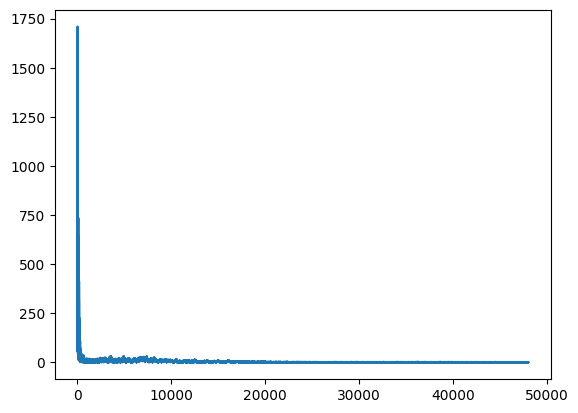

In [73]:
#получаем spectrum
spectrum1 = seg1.make_spectrum()
spectrum1.plot()

Можем заметить, что мощность сосредоточена на низких частотах, возможно это красный шум.

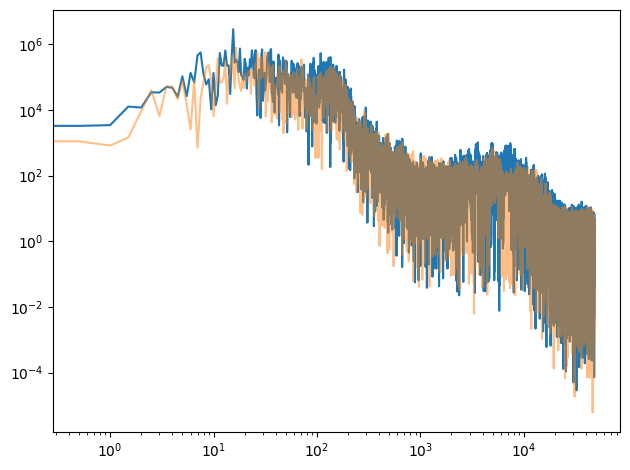

In [74]:
#представим спектр мощности в логарифмическом масштабе
spectrum1.plot_power()
tdsp.decorate(xscale='log', yscale='log')

#проверим, как спектр изменяется со временем
spectrum2 = seg2.make_spectrum()
spectrum2.plot_power(alpha=0.5)
tdsp.decorate(xscale='log', yscale='log')

После f=10^2 спектр и правда постепенно идет вниз (однако нелинейно), соответственно этот звук можно назвать близким к красному шуму.

Видно, что структура спектра для второго сегмента также похожа по форме, т.е. можно сказать, что шум примерно один и тот же.

##Упражнение 4.2
Реализация метода Бартлетта и оценка спектра мощности шумового сигнала.

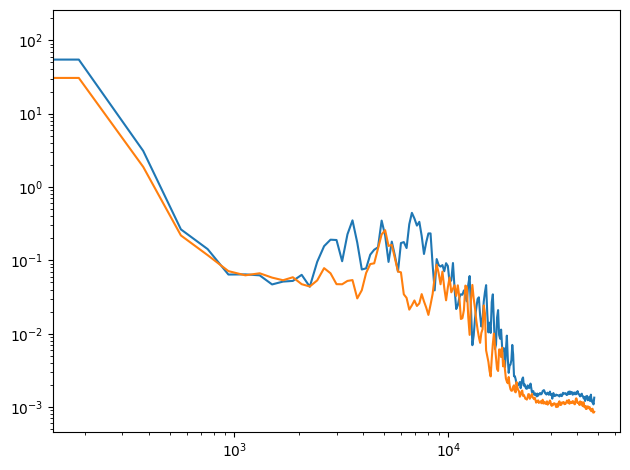

In [75]:
#метод Бартлетта
def bartlett_method(wave, seg_length=512, win_flag=True):
    #создадим спектрограммы и получение отдельных спектров
    spectro = wave.make_spectrogram(seg_length, win_flag)
    spectrums = spectro.spec_map.values()
    #получим массивы мощности
    psds = [spectrum.power for spectrum in spectrums]
    #вычислим среднеквадр.мощность
    hs = np.sqrt(sum(psds) / len(psds))
    fs = next(iter(spectrums)).fs
    #составим итоговый спектр
    spectrum = tdsp.Spectrum(hs, fs, wave.framerate)
    return spectrum

#проверка на сигналах
bm1 = bartlett_method(seg1)
bm2 = bartlett_method(seg2)

bm1.plot_power()
bm2.plot_power()
tdsp.decorate(xscale='log', yscale='log')

Зависимость мощности от частоты прослеживается более явно.

##Упражнение 4.3

Не смог разобраться с сайтом, поэтому буду работать на данных автора о BTC.

In [77]:
if not os.path.exists('BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv

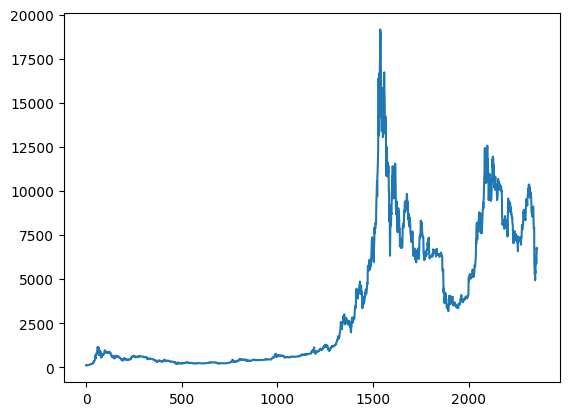

In [78]:
#используем pandas для чтения данных
import pandas as pd
data = pd.read_csv('BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv',
                 parse_dates=[0])
ys = data['Closing Price (USD)']
ts = data.index
#создадим wave на основе этих данных
wave = tdsp.Wave(ys, ts, framerate=1)
wave.plot()

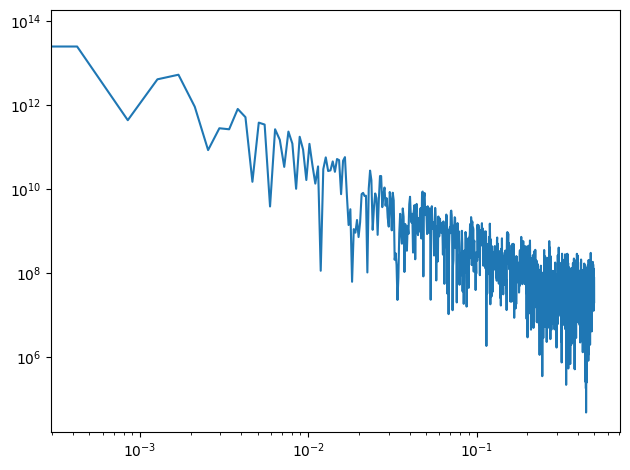

In [79]:
#получим спектр мощности
spectrum = wave.make_spectrum()
spectrum.plot_power()
tdsp.decorate(xscale='log', yscale='log')

можем заметить линейную зависимость между мощностью и частотой. Соответственно это либо розовый, либо красный шум.

Это логично, так как каждое значение для BTC вычисляется через прибавление к предыдущему изменения цены (по сути как в броуновском шуме).

In [81]:
#проверим наклон спектра
spectrum.estimate_slope()[0]

np.float64(-1.7332540936758924)

Наклон недостаточен для красного шума (2 и выше), соответственно это розовый шум.

##Упражнение 4.4
Пуассоновский шум


In [83]:
#класс UncPoissonNoise

class UncPoissonNoise(tdsp.Noise):
    def evaluate(self, ts):
        ys = np.random.poisson(self.amp, len(ts))
        return ys


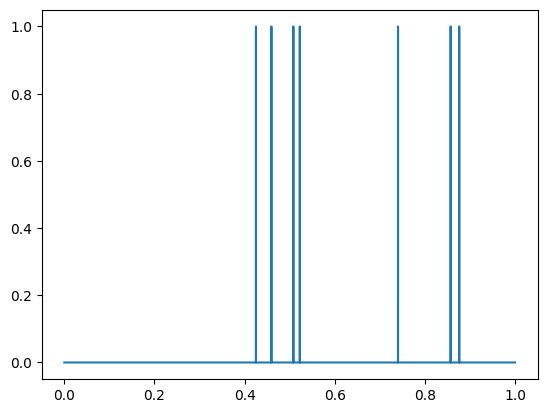

In [88]:
#сгенерируем шум
sig = UncPoissonNoise(amp=0.001)
wave = sig.make_wave(duration=1, framerate=10000)
wave.plot()
wave.make_audio()

np.float64(0.0019087675333595265)

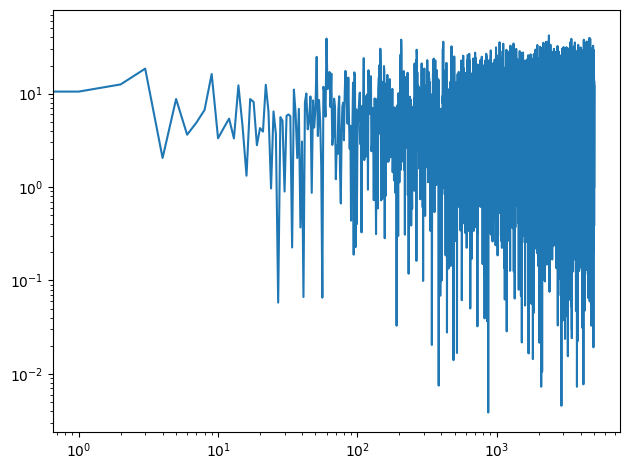

In [90]:
#получим спектр мощности
spectrum = wave.make_spectrum()
spectrum.plot_power()
tdsp.decorate(xscale='log', yscale='log')

#проверим уклон
spectrum.estimate_slope()[0]

Спектр мощности визуально похож на белый шум, значение уклона, близкое к нулю, это подтверждает.

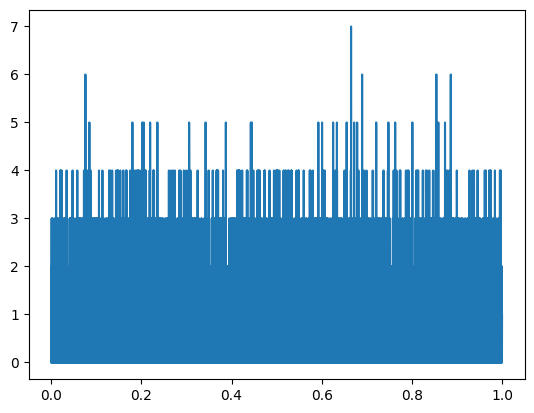

In [92]:
#увеличим значение аплитуды
sig = UncPoissonNoise(amp=1)
wave = sig.make_wave(duration=1, framerate=10000)
wave.plot()
wave.make_audio()

np.float64(0.023589812515427296)

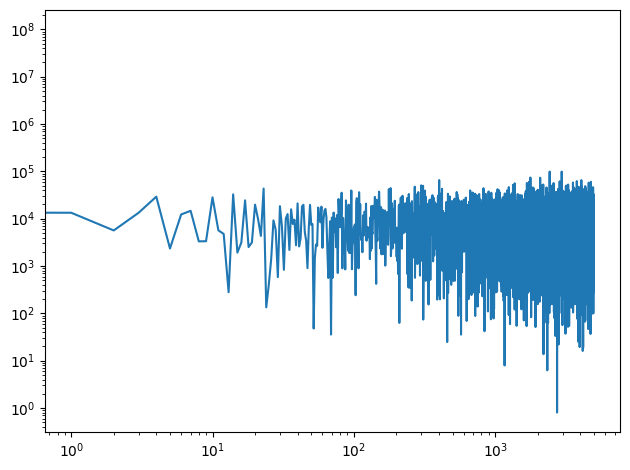

In [93]:
#получим спектр мощности
spectrum = wave.make_spectrum()
spectrum.plot_power()
tdsp.decorate(xscale='log', yscale='log')

#проверим уклон
spectrum.estimate_slope()[0]

Шум стал больше похож на белый по звучанию. Спектр мощности и уклон также показывают это.

##Упражнение 4.5
Другой алгоритм генерации розового шума

np.float64(-1.0218847510914923)

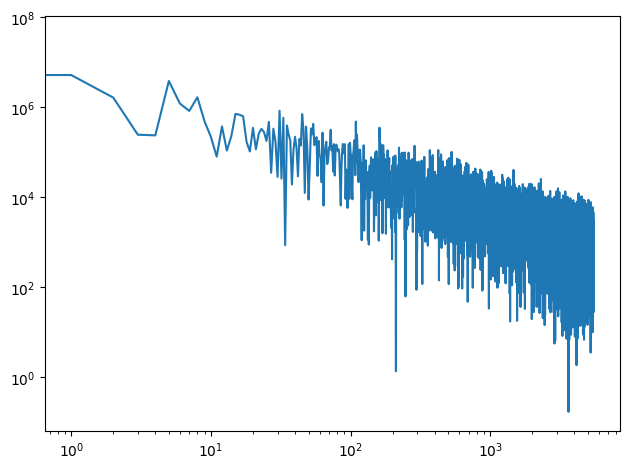

In [96]:
def voss_mccartney_pink_noise(num_samples, num_rows=16, random_seed=None):
    rng = np.random.default_rng(random_seed)
    #создаем начальные значения
    rows = rng.uniform(-1, 1, num_rows)
    output = np.zeros(num_samples)
    #процесс генерации
    for i in range(num_samples):
        for j in range(num_rows):
            if (i & (2**j - 1)) == 0:
                rows[j] = rng.uniform(-1, 1)

        output[i] = np.sum(rows)

    if np.std(output) > 0:
        output /= np.std(output)

    return output

#тест
pink_sig = voss_mccartney_pink_noise(11025)
pink_wave = tdsp.Wave(pink_sig)
pink_spectrum = pink_wave.make_spectrum()

#получим спектр мощности
pink_spectrum.plot_power()
tdsp.decorate(xscale='log', yscale='log')

#проверим уклон
pink_spectrum.estimate_slope()[0]
